# Robustness Survey
## 

C:\Users\takahashi\PyTools\Data\20161104\BL-10C\Ald


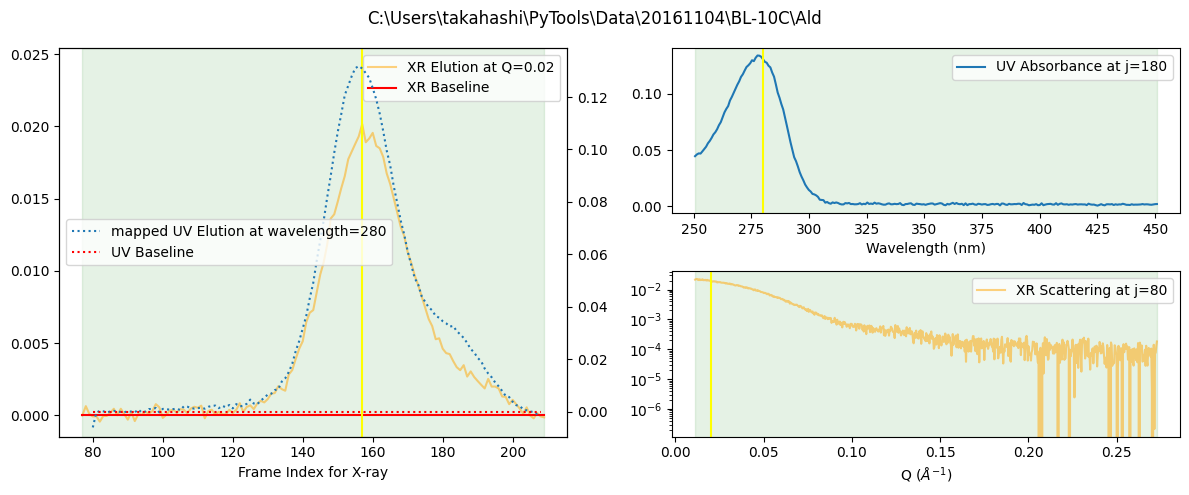

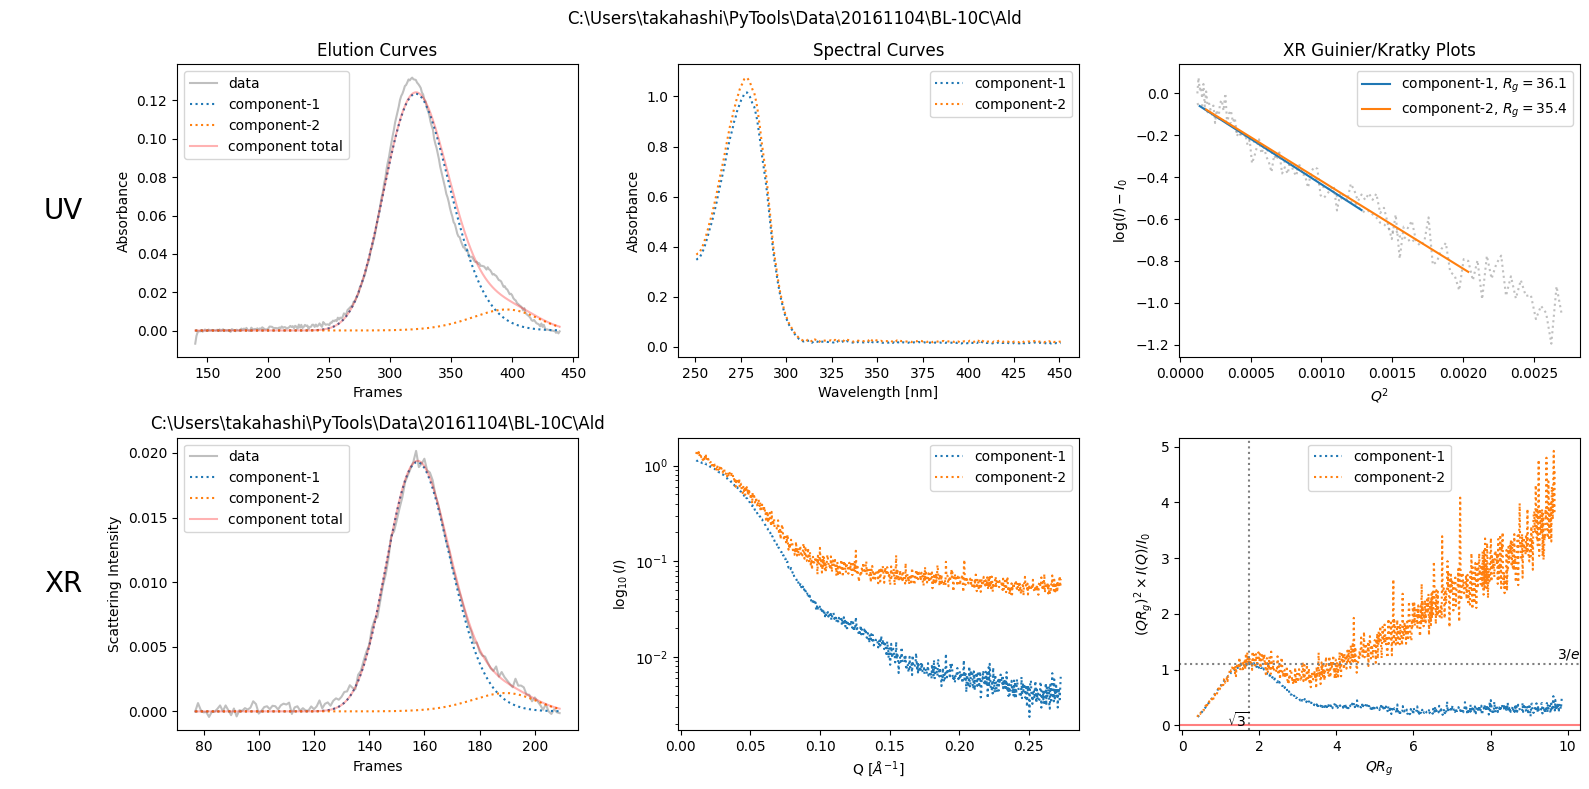

In [ ]:
import sys
sys.path.insert(0, '../../../molass-library')
sys.path.insert(0, '../../../molass-legacy')
import os
import matplotlib.pyplot as plt
from molass import get_version
get_version() >= '0.7.4', "Please update molass to version 0.7.4 or higher."
from molass.Local import get_local_settings
from molass.DataUtils.FolderWalker import walk_folders
from molass.Global.Options import set_molass_options
set_molass_options(flowchange='auto')
local_settings = get_local_settings()
DATA_ROOT_FOLDER = local_settings['DATA_ROOT_FOLDER']
from molass.DataObjects import SecSaxsData as SSD

output_folder = "figs"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

path = os.path.join(DATA_ROOT_FOLDER, "20161104", "BL-10C", "Ald")
print(path)
ssd = SSD(path)

trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
corrected_ssd.plot_compact(title=path, baseline=True)
decomposition = corrected_ssd.quick_decomposition(num_components=2)
decomposition.plot_components(title=path)

area= 0.6102249259024266


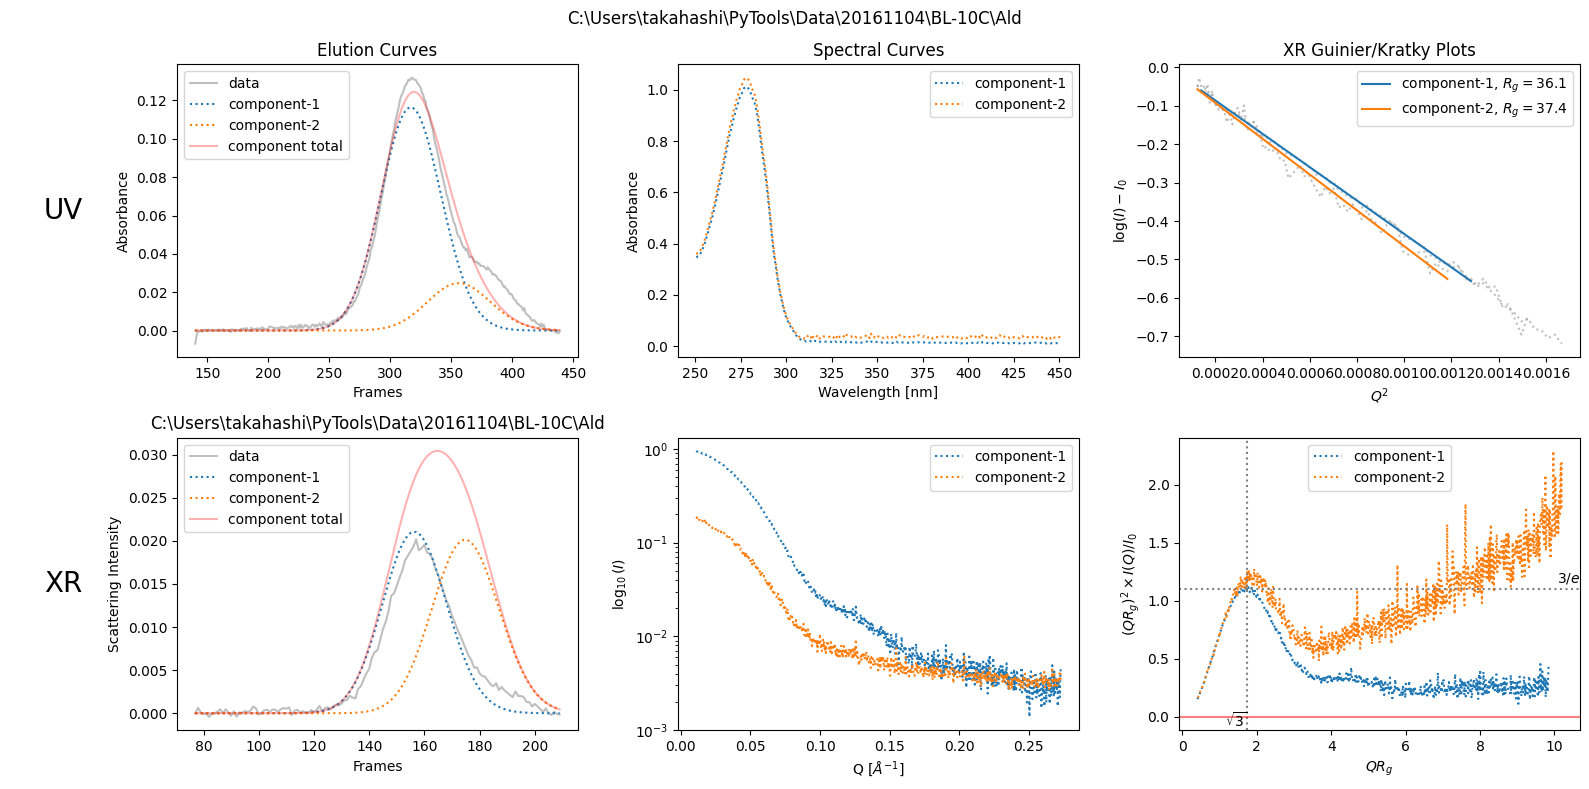

In [2]:
sdm_decomposition = decomposition.optimize_with_model('SDM', model_params=dict(timescale=70))
sdm_decomposition.plot_components(title=path)